# NUS Orbital 2026 FinSight
## Machine Learning Model to predict the risk of overspending budget
Budgets are dead when it comes to just limit the amount one will spend for a specific category. In actual fact, what will be the actual risk when it comes to overspending?

### 1. Importing Relevant Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.model_selection import GroupKFold

### 2. Reading and extracting data out for analysis

In [2]:
budget_df = pd.read_csv("../data/raw_data/budgets.csv")
transaction_df = pd.read_csv("../data/raw_data/transactions.csv")
category_df = pd.read_csv("../data/raw_data/transactionsCat.csv")


In [3]:
budget_df.head()

,budgetID,userID,catID,budgetStartDate,budgetEndDate,budgetLimit,budgetName,budgetDesc,budgetFreq
0,e5a123b9-cf57-4eab-a670-f3a65f7ab93e,550e8400-e29b-41d4-a716-446655440000,6dab2073-ff40-4704-8a15-0d3593de8c52,2026-06-01,2026-06-30,400.0,Food Budget,Monthly spending on food,monthly
1,31fa82bf-26da-4ada-ab01-4a01477b971a,550e8400-e29b-41d4-a716-446655440000,26834e16-112d-49cd-bdc2-f5c8c7c1144e,2026-06-01,2026-06-30,120.0,Transport Budget,Public transport spending,monthly
2,d5423f69-08cf-4445-9267-cf76c0e050fd,86716dc1-061e-4879-bd5b-ab4701d22dc6,e5844fa7-c620-4d55-a4b4-2b4d437950fb,2026-06-01,2026-06-30,100.0,Utilities Budget,Bills and utilities,monthly
3,13cd2288-611e-4c45-8e2e-c7750aca86a3,bbeb7d1c-4820-481a-84b6-302371fb9a50,26834e16-112d-49cd-bdc2-f5c8c7c1144e,2026-05-31,2026-06-29,100.0,Transport,🚍|,monthly
4,ca1b80e6-b308-453c-913e-f549eff8bda7,bbeb7d1c-4820-481a-84b6-302371fb9a50,6dab2073-ff40-4704-8a15-0d3593de8c52,2026-06-01,2026-06-30,200.0,Food,🍔|...,monthly


In [4]:
transaction_df.head()

,transID,userID,catID,transAmt,transDate,createdAt,updatedAt,transDesc,transPaymentMethod
0,abb0d49b-0bad-467b-900a-24d501ed7e34,550e8400-e29b-41d4-a716-446655440000,6dab2073-ff40-4704-8a15-0d3593de8c52,25.5,2026-06-10,2026-06-11 19:23:59.582286,2026-06-11 19:23:59.582286,Dinner at hawker center,Cash
1,3d300f28-1510-47b2-a7ed-db8442979c92,550e8400-e29b-41d4-a716-446655440000,26834e16-112d-49cd-bdc2-f5c8c7c1144e,2.0,2026-06-09,2026-06-11 19:23:59.582286,2026-06-11 19:23:59.582286,MRT fare to work,EZ-Link
2,ef96d48a-c0b8-47cd-bf62-92ef3b2f281f,550e8400-e29b-41d4-a716-446655440000,cc8cf728-fe77-4f13-b7dd-9de973ae6183,5000.0,2026-06-01,2026-06-11 19:23:59.582286,2026-06-11 19:23:59.582286,Monthly salary credited,Bank Transfer
3,c057b01b-0d61-49d8-9d6e-3fe0ab9ece59,86716dc1-061e-4879-bd5b-ab4701d22dc6,6dab2073-ff40-4704-8a15-0d3593de8c52,18.9,2026-06-11,2026-06-11 19:23:59.582286,2026-06-11 19:23:59.582286,Lunch at food court,Cash
4,a2ad58e2-0903-4f91-85d6-a12d8285a6d8,86716dc1-061e-4879-bd5b-ab4701d22dc6,e5844fa7-c620-4d55-a4b4-2b4d437950fb,60.0,2026-06-08,2026-06-11 19:23:59.582286,2026-06-11 19:23:59.582286,Internet bill payment,Credit Card


In [5]:
category_df.head()

,catID,catName,catDesc,catType
0,6dab2073-ff40-4704-8a15-0d3593de8c52,Food & Dining,"Meals, restaurants, coffee, snacks",expense
1,26834e16-112d-49cd-bdc2-f5c8c7c1144e,Transport,"Public transport, Grab, fuel, tolls",expense
2,cc8cf728-fe77-4f13-b7dd-9de973ae6183,Salary,Monthly employment income,income
3,51efabd6-edc4-48c6-8e69-a4d2cc58ca34,Entertainment,"Movies, games, streaming services",expense
4,e5844fa7-c620-4d55-a4b4-2b4d437950fb,Utilities,"Electricity, water, internet bills",expense


In [6]:
transaction_df = transaction_df.merge(
    category_df[['catID', 'catName']],
    on='catID',
    how='left'
)

In [7]:
transaction_df.head()

,transID,userID,catID,transAmt,transDate,createdAt,updatedAt,transDesc,transPaymentMethod,catName
0,abb0d49b-0bad-467b-900a-24d501ed7e34,550e8400-e29b-41d4-a716-446655440000,6dab2073-ff40-4704-8a15-0d3593de8c52,25.5,2026-06-10,2026-06-11 19:23:59.582286,2026-06-11 19:23:59.582286,Dinner at hawker center,Cash,Food & Dining
1,3d300f28-1510-47b2-a7ed-db8442979c92,550e8400-e29b-41d4-a716-446655440000,26834e16-112d-49cd-bdc2-f5c8c7c1144e,2.0,2026-06-09,2026-06-11 19:23:59.582286,2026-06-11 19:23:59.582286,MRT fare to work,EZ-Link,Transport
2,ef96d48a-c0b8-47cd-bf62-92ef3b2f281f,550e8400-e29b-41d4-a716-446655440000,cc8cf728-fe77-4f13-b7dd-9de973ae6183,5000.0,2026-06-01,2026-06-11 19:23:59.582286,2026-06-11 19:23:59.582286,Monthly salary credited,Bank Transfer,Salary
3,c057b01b-0d61-49d8-9d6e-3fe0ab9ece59,86716dc1-061e-4879-bd5b-ab4701d22dc6,6dab2073-ff40-4704-8a15-0d3593de8c52,18.9,2026-06-11,2026-06-11 19:23:59.582286,2026-06-11 19:23:59.582286,Lunch at food court,Cash,Food & Dining
4,a2ad58e2-0903-4f91-85d6-a12d8285a6d8,86716dc1-061e-4879-bd5b-ab4701d22dc6,e5844fa7-c620-4d55-a4b4-2b4d437950fb,60.0,2026-06-08,2026-06-11 19:23:59.582286,2026-06-11 19:23:59.582286,Internet bill payment,Credit Card,Utilities


In [8]:
budget_df['budgetStartDate'] = pd.to_datetime(budget_df['budgetStartDate'])
budget_df['budgetEndDate'] = pd.to_datetime(budget_df['budgetEndDate'])
transaction_df['transDate'] = pd.to_datetime(transaction_df['transDate'])

In [9]:
training_df = []

In [ ]:
for _, budget in budget_df.iterrows():

    budget_id = budget['budgetID']
    user = budget['userID']
    category = budget['catID']

    start = budget['budgetStartDate']
    end = budget['budgetEndDate']

    budget_limit = budget['budgetLimit']
    budget_freq = budget['budgetFreq']

    transactions = transaction_df[
        (transaction_df['userID'] == user) &
        (transaction_df['catID'] == category) &
        (transaction_df['transDate'] >= start) &
        (transaction_df['transDate'] <= end)
    ].copy()

    transactions = transactions.sort_values('transDate')

    final_spent = transactions['transAmt'].sum()
    overspent = int(final_spent > budget_limit)

    snapshot_dates = pd.date_range(
        start=start,
        end=end,
        freq='2D'
    )

    for snapshot in snapshot_dates:

        snapshot_transactions = transactions[
            transactions['transDate'] <= snapshot
        ]

        total_spent = snapshot_transactions['transAmt'].sum()
        num_transactions = len(snapshot_transactions)
        avg_transaction = snapshot_transactions['transAmt'].mean()
        max_transaction = snapshot_transactions['transAmt'].max()
        std_transaction = snapshot_transactions['transAmt'].std()

        budget_utilization = total_spent / budget_limit
        remaining_budget = budget_limit - total_spent

        days_elapsed = (snapshot - start).days + 1
        budget_duration = (end - start).days + 1
        days_remaining = (end - snapshot).days

        training_df.append({
            "budgetID": budget_id,
            "userID": user,
            "budgetName": budget["budgetName"],
            "budgetFreq": budget_freq,
            "budgetLimit": budget_limit,
            "daysElapsed": days_elapsed,
            "daysRemaining": days_remaining,
            "budgetDuration": budget_duration,
            "totalSpent": total_spent,
            "numTransactions": num_transactions,
            "avgTransaction": avg_transaction,
            "maxTransaction": max_transaction,
            "stdTransaction": std_transaction,
            "budgetUtilization": budget_utilization,
            "remainingBudget": remaining_budget,
            "overspent": overspent
        })


In [11]:
training_df = pd.DataFrame(training_df)
training_df.head(20)

,budgetID,userID,budgetName,budgetFreq,budgetLimit,daysElapsed,daysRemaining,budgetDuration,totalSpent,numTransactions,avgTransaction,maxTransaction,stdTransaction,budgetUtilization,remainingBudget,overspent
0,e5a123b9-cf57-4eab-a670-f3a65f7ab93e,550e8400-e29b-41d4-a716-446655440000,Food Budget,monthly,400.0,1,29,30,0.00,0,NaN,NaN,NaN,0.000000,400.00,0
1,e5a123b9-cf57-4eab-a670-f3a65f7ab93e,550e8400-e29b-41d4-a716-446655440000,Food Budget,monthly,400.0,3,27,30,16.48,2,8.240000,8.39,0.212132,0.041200,383.52,0
2,e5a123b9-cf57-4eab-a670-f3a65f7ab93e,550e8400-e29b-41d4-a716-446655440000,Food Budget,monthly,400.0,5,25,30,16.48,2,8.240000,8.39,0.212132,0.041200,383.52,0
3,e5a123b9-cf57-4eab-a670-f3a65f7ab93e,550e8400-e29b-41d4-a716-446655440000,Food Budget,monthly,400.0,7,23,30,53.16,5,10.632000,14.71,3.016939,0.132900,346.84,0
4,e5a123b9-cf57-4eab-a670-f3a65f7ab93e,550e8400-e29b-41d4-a716-446655440000,Food Budget,monthly,400.0,9,21,30,99.03,10,9.903000,14.71,2.862439,0.247575,300.97,0
5,e5a123b9-cf57-4eab-a670-f3a65f7ab93e,550e8400-e29b-41d4-a716-446655440000,Food Budget,monthly,400.0,11,19,30,158.96,15,10.597333,25.50,4.849896,0.397400,241.04,0
6,e5a123b9-cf57-4eab-a670-f3a65f7ab93e,550e8400-e29b-41d4-a716-446655440000,Food Budget,monthly,400.0,13,17,30,184.93,18,10.273889,25.50,4.672956,0.462325,215.07,0
7,e5a123b9-cf57-4eab-a670-f3a65f7ab93e,550e8400-e29b-41d4-a716-446655440000,Food Budget,monthly,400.0,15,15,30,194.66,19,10.245263,25.50,4.543011,0.486650,205.34,0
8,e5a123b9-cf57-4eab-a670-f3a65f7ab93e,550e8400-e29b-41d4-a716-446655440000,Food Budget,monthly,400.0,17,13,30,236.74,24,9.864167,25.50,4.186981,0.591850,163.26,0
9,e5a123b9-cf57-4eab-a670-f3a65f7ab93e,550e8400-e29b-41d4-a716-446655440000,Food Budget,monthly,400.0,19,11,30,236.74,24,9.864167,25.50,4.186981,0.591850,163.26,0


In [12]:
training_df.shape


(3970, 16)

In [13]:
training_df.isnull().sum()

budgetID               0
userID                 0
budgetName             0
budgetFreq             0
budgetLimit            0
daysElapsed            0
daysRemaining          0
budgetDuration         0
totalSpent             0
numTransactions        0
avgTransaction       355
maxTransaction       355
stdTransaction       640
budgetUtilization      0
remainingBudget        0
overspent              0
dtype: int64

In [14]:
### imputing nan values with the average values of the respective columns

training_df['avgTransaction'] = training_df['avgTransaction'].fillna(training_df['avgTransaction'].mean())
training_df['maxTransaction'] = training_df['maxTransaction'].fillna(training_df['maxTransaction'].mean())
training_df['stdTransaction'] = training_df['stdTransaction'].fillna(training_df['stdTransaction'].mean())

In [15]:
training_df.isnull().sum()

budgetID             0
userID               0
budgetName           0
budgetFreq           0
budgetLimit          0
daysElapsed          0
daysRemaining        0
budgetDuration       0
totalSpent           0
numTransactions      0
avgTransaction       0
maxTransaction       0
stdTransaction       0
budgetUtilization    0
remainingBudget      0
overspent            0
dtype: int64

In [16]:
training_df['budgetFreq'].value_counts()

budgetFreq
monthly    3970
Name: count, dtype: int64

In [ ]:
## encoding categorical variables using OneHotEncoder

encoder = OneHotEncoder(
    categories=[['weekly', 'biweekly', 'monthly']],
    handle_unknown='ignore',
    sparse_output=False
)
encoded_array = encoder.fit_transform(training_df[['budgetFreq']])

df_encoded = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(['budgetFreq']),
    index=training_df.index  # Keep the same index
)

training_df = training_df.drop(columns=['budgetFreq'])

# Combine
training_df = pd.concat([training_df, df_encoded], axis=1)

training_df.head()


,budgetID,userID,budgetName,budgetLimit,daysElapsed,daysRemaining,budgetDuration,totalSpent,numTransactions,avgTransaction,maxTransaction,stdTransaction,budgetUtilization,remainingBudget,overspent,budgetFreq_weekly,budgetFreq_biweekly,budgetFreq_monthly
0,e5a123b9-cf57-4eab-a670-f3a65f7ab93e,550e8400-e29b-41d4-a716-446655440000,Food Budget,400.0,1,29,30,0.00,0,13.030327,19.502736,4.154645,0.000000,400.00,0,0.0,0.0,1.0
1,e5a123b9-cf57-4eab-a670-f3a65f7ab93e,550e8400-e29b-41d4-a716-446655440000,Food Budget,400.0,3,27,30,16.48,2,8.240000,8.390000,0.212132,0.041200,383.52,0,0.0,0.0,1.0
2,e5a123b9-cf57-4eab-a670-f3a65f7ab93e,550e8400-e29b-41d4-a716-446655440000,Food Budget,400.0,5,25,30,16.48,2,8.240000,8.390000,0.212132,0.041200,383.52,0,0.0,0.0,1.0
3,e5a123b9-cf57-4eab-a670-f3a65f7ab93e,550e8400-e29b-41d4-a716-446655440000,Food Budget,400.0,7,23,30,53.16,5,10.632000,14.710000,3.016939,0.132900,346.84,0,0.0,0.0,1.0
4,e5a123b9-cf57-4eab-a670-f3a65f7ab93e,550e8400-e29b-41d4-a716-446655440000,Food Budget,400.0,9,21,30,99.03,10,9.903000,14.710000,2.862439,0.247575,300.97,0,0.0,0.0,1.0


In [18]:
training_df['budgetName'].value_counts()

budgetName
Food & Dining Budget    1040
Entertainment Budget    1021
Utilities Budget         919
Transport Budget         898
Food                      47
Food Budget               15
Transport                 15
Bills                     15
Name: count, dtype: int64

In [19]:
budget_name_map = {
    'Food & Dining Budget': 'Food',
    'Food Budget': 'Food',
    'Food': 'Food',

    'Transport Budget': 'Transport',
    'Transport': 'Transport',

    'Utilities Budget': 'Utilities',
    'Bills': 'Utilities',

    'Entertainment Budget': 'Entertainment'
}

training_df['budgetName'] = training_df['budgetName'].replace(budget_name_map)

In [20]:
training_df['budgetName'].value_counts()

budgetName
Food             1102
Entertainment    1021
Utilities         934
Transport         913
Name: count, dtype: int64

In [ ]:
encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)

encoded_array = encoder.fit_transform(training_df[['budgetName']])

df_budget_encoded = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(['budgetName']),
    index=training_df.index
)

training_df = training_df.drop(columns=['budgetName'])
training_df = pd.concat([training_df, df_budget_encoded], axis=1)

training_df.head()

,budgetID,userID,budgetLimit,daysElapsed,daysRemaining,budgetDuration,totalSpent,numTransactions,avgTransaction,maxTransaction,...,budgetUtilization,remainingBudget,overspent,budgetFreq_weekly,budgetFreq_biweekly,budgetFreq_monthly,budgetName_Entertainment,budgetName_Food,budgetName_Transport,budgetName_Utilities
0,e5a123b9-cf57-4eab-a670-f3a65f7ab93e,550e8400-e29b-41d4-a716-446655440000,400.0,1,29,30,0.00,0,13.030327,19.502736,...,0.000000,400.00,0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,e5a123b9-cf57-4eab-a670-f3a65f7ab93e,550e8400-e29b-41d4-a716-446655440000,400.0,3,27,30,16.48,2,8.240000,8.390000,...,0.041200,383.52,0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,e5a123b9-cf57-4eab-a670-f3a65f7ab93e,550e8400-e29b-41d4-a716-446655440000,400.0,5,25,30,16.48,2,8.240000,8.390000,...,0.041200,383.52,0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,e5a123b9-cf57-4eab-a670-f3a65f7ab93e,550e8400-e29b-41d4-a716-446655440000,400.0,7,23,30,53.16,5,10.632000,14.710000,...,0.132900,346.84,0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,e5a123b9-cf57-4eab-a670-f3a65f7ab93e,550e8400-e29b-41d4-a716-446655440000,400.0,9,21,30,99.03,10,9.903000,14.710000,...,0.247575,300.97,0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [22]:
### userID not needed for training model
training_df.drop(columns=['userID'], inplace=True)

# Keep budgetID for grouping, separate from the feature matrix
groups = training_df['budgetID']
training_df.drop(columns=['budgetID'], inplace=True)


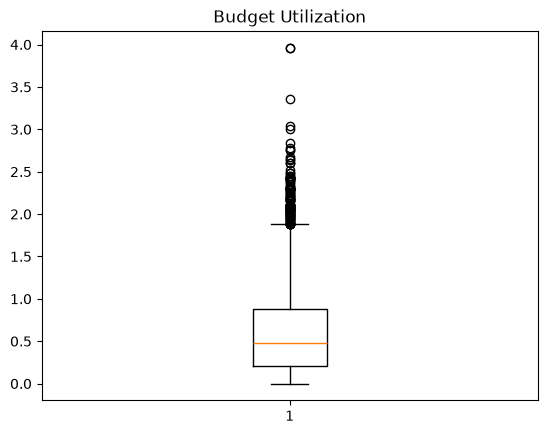

In [23]:
### transAmt boxplot for outliers
plt.boxplot(training_df['budgetUtilization'])
plt.title("Budget Utilization")
plt.show()

### Model Training

In [24]:
training_df['overspent'].value_counts(normalize=True)

overspent
1    0.55466
0    0.44534
Name: proportion, dtype: float64

In [ ]:
x = training_df.drop(columns=['overspent'])
y = training_df['overspent']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(x, y, groups=groups))

X_train, X_test = x.iloc[train_idx], x.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Sanity check: confirm no budget leaks across the split
train_groups = set(groups.iloc[train_idx])
test_groups = set(groups.iloc[test_idx])
print("Overlapping budgets between train/test:", len(train_groups & test_groups))




Overlapping budgets between train/test: 0


In [26]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [27]:
y_pred = rf.predict(X_test)

y_prob = rf.predict_proba(X_test)[:, 1]

In [28]:
auc = roc_auc_score(y_test, y_prob)
accuracy = accuracy_score(y_test, y_pred)

print("ROC AUC:", auc)
print("Accuracy:", accuracy)

ROC AUC: 0.9603179099779666
Accuracy: 0.8767123287671232


In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.77      0.85       353
           1       0.84      0.96      0.90       450

    accuracy                           0.88       803
   macro avg       0.89      0.87      0.87       803
weighted avg       0.88      0.88      0.87       803



In [30]:
importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)


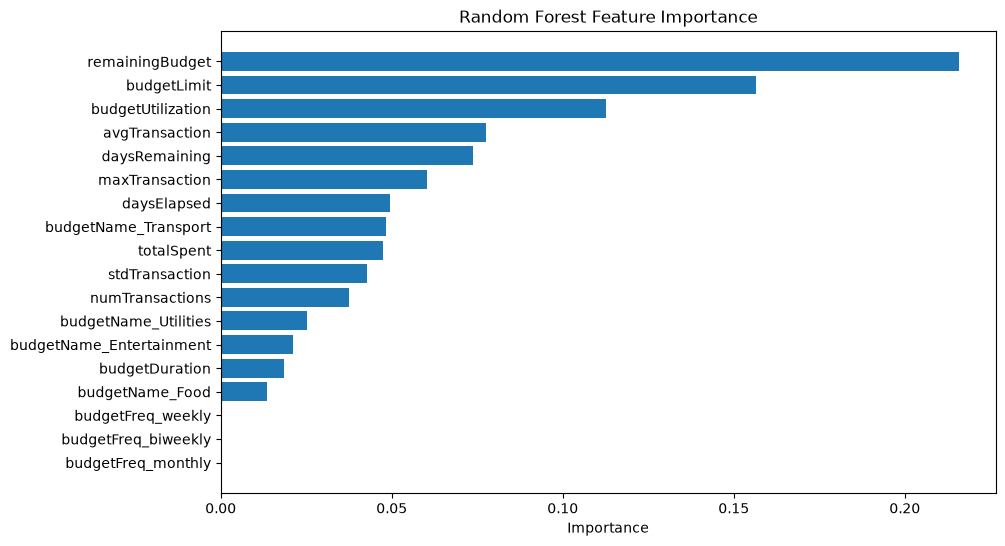

In [31]:

plt.figure(figsize=(10,6))
plt.barh(
    importance['Feature'],
    importance['Importance']
)
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")

plt.show()

In [32]:
# Requires daysElapsed / budgetDuration still present in X_test
eval_df = X_test.copy()
eval_df['y_true'] = y_test.values
eval_df['y_prob'] = y_prob
eval_df['pct_elapsed'] = eval_df['daysElapsed'] / eval_df['budgetDuration']

bins = [0, 0.25, 0.5, 0.75, 1.0]
labels = ['0-25%', '25-50%', '50-75%', '75-100%']
eval_df['elapsed_bucket'] = pd.cut(eval_df['pct_elapsed'], bins=bins, labels=labels, include_lowest=True)

for bucket in labels:
    subset = eval_df[eval_df['elapsed_bucket'] == bucket]
    if len(subset) > 1 and subset['y_true'].nunique() > 1:
        bucket_auc = roc_auc_score(subset['y_true'], subset['y_prob'])
        print(f"{bucket}: n={len(subset)}, AUC={bucket_auc:.3f}")
    else:
        print(f"{bucket}: n={len(subset)}, AUC=N/A (not enough class variety)")


0-25%: n=208, AUC=0.907
25-50%: n=202, AUC=0.947
50-75%: n=191, AUC=0.974
75-100%: n=202, AUC=0.996


In [33]:
# Risk score = probability of eventual overspend, at any snapshot in time
risk_scores = rf.predict_proba(X_test)[:, 1]

# Attach back to something interpretable
risk_df = X_test.copy()
risk_df['riskScore'] = risk_scores
risk_df['actualOutcome'] = y_test.values
risk_df.head()

,budgetLimit,daysElapsed,daysRemaining,budgetDuration,totalSpent,numTransactions,avgTransaction,maxTransaction,stdTransaction,budgetUtilization,remainingBudget,budgetFreq_weekly,budgetFreq_biweekly,budgetFreq_monthly,budgetName_Entertainment,budgetName_Food,budgetName_Transport,budgetName_Utilities,riskScore,actualOutcome
0,400.0,1,29,30,0.00,0,13.030327,19.502736,4.154645,0.000000,400.00,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.43,0
1,400.0,3,27,30,16.48,2,8.240000,8.390000,0.212132,0.041200,383.52,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.26,0
2,400.0,5,25,30,16.48,2,8.240000,8.390000,0.212132,0.041200,383.52,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.26,0
3,400.0,7,23,30,53.16,5,10.632000,14.710000,3.016939,0.132900,346.84,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.29,0
4,400.0,9,21,30,99.03,10,9.903000,14.710000,2.862439,0.247575,300.97,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.22,0


In [34]:
def risk_band(p):
    if p < 0.4:
        return "Low"
    elif p < 0.8:
        return "Medium"
    else:
        return "High"

risk_df['riskLevel'] = risk_df['riskScore'].apply(risk_band)
risk_df[['riskScore', 'riskLevel']].head()

,riskScore,riskLevel
0,0.43,Medium
1,0.26,Low
2,0.26,Low
3,0.29,Low
4,0.22,Low


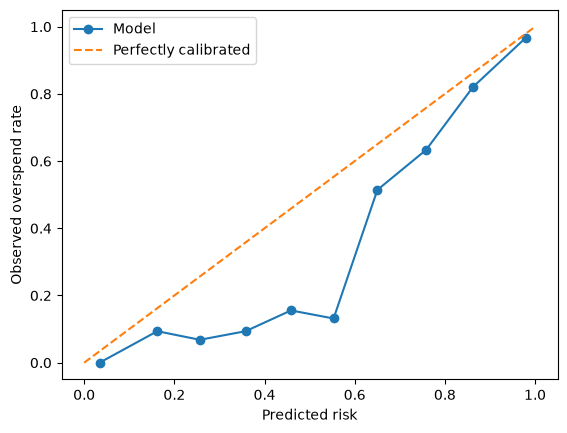

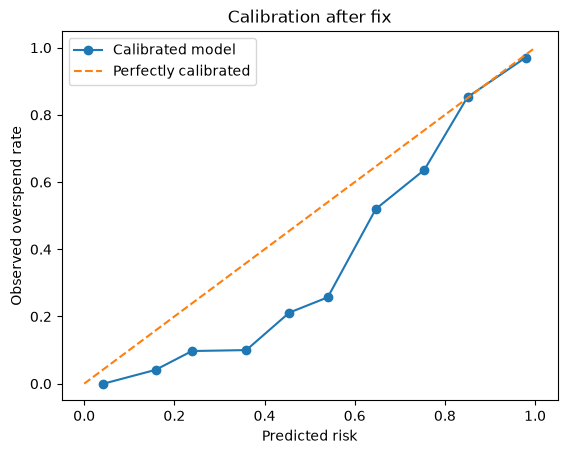

In [37]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.model_selection import GroupKFold

# Check: does predicted risk match observed frequency?
prob_true, prob_pred = calibration_curve(y_test, risk_scores, n_bins=10)
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0,1], [0,1], linestyle='--', label='Perfectly calibrated')
plt.xlabel('Predicted risk')
plt.ylabel('Observed overspend rate')
plt.legend()
plt.show()

# Calibrate using a GROUP-AWARE cv split, so no budget's snapshots straddle
# a fold between the internal RF fit and the isotonic calibration fit.


group_cv = GroupKFold(n_splits=5)

# Materialize the splits into a plain list — a generator here would break
# joblib.dump() later, since generators aren't picklable.
train_groups_series = groups.loc[X_train.index]
group_splits = list(group_cv.split(X_train, y_train, groups=train_groups_series))

calibrated_rf = CalibratedClassifierCV(
    RandomForestClassifier(n_estimators=100, random_state=42),
    method='isotonic',
    cv=group_splits
)
calibrated_rf.fit(X_train, y_train)
calibrated_risk_scores = calibrated_rf.predict_proba(X_test)[:, 1]

# Re-check calibration after fixing it
cal_prob_true, cal_prob_pred = calibration_curve(y_test, calibrated_risk_scores, n_bins=10)
plt.plot(cal_prob_pred, cal_prob_true, marker='o', label='Calibrated model')
plt.plot([0,1], [0,1], linestyle='--', label='Perfectly calibrated')
plt.xlabel('Predicted risk')
plt.ylabel('Observed overspend rate')
plt.legend()
plt.title('Calibration after fix')
plt.show()


In [38]:
import joblib
from pathlib import Path

MODELS_DIR = Path("../models") if Path("../models").exists() else Path("models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(calibrated_rf, MODELS_DIR / "overspend_risk_model.pkl")
joblib.dump(list(X_train.columns), MODELS_DIR / "model_feature_columns.pkl")

print("Saved:")
print(" -", MODELS_DIR / "overspend_risk_model.pkl")
print(" -", MODELS_DIR / "model_feature_columns.pkl")
print("\nFeature columns (order matters):")
print(list(X_train.columns))


Saved:
 - ../models/overspend_risk_model.pkl
 - ../models/model_feature_columns.pkl

Feature columns (order matters):
['budgetLimit', 'daysElapsed', 'daysRemaining', 'budgetDuration', 'totalSpent', 'numTransactions', 'avgTransaction', 'maxTransaction', 'stdTransaction', 'budgetUtilization', 'remainingBudget', 'budgetFreq_weekly', 'budgetFreq_biweekly', 'budgetFreq_monthly', 'budgetName_Entertainment', 'budgetName_Food', 'budgetName_Transport', 'budgetName_Utilities']
